# Analisa A/B Testing: Optimalisasi Digital Marketing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Coolyeah/Analisa-Bisnis/digital_marketing_campaign_dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [4]:
df.sample(10)

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
5549,13549,38,Male,139509,Referral,Awareness,7032.077949,0.117096,0.019807,44,8.198850,12.456495,30,6,4,8,715,IsConfid,ToolConfid,1
3884,11884,66,Female,134639,SEO,Awareness,9822.279150,0.228477,0.111054,9,4.555221,8.008864,22,0,6,6,1818,IsConfid,ToolConfid,1
2914,10914,22,Female,131372,PPC,Consideration,9049.953823,0.277626,0.132456,4,2.396065,8.507161,51,15,3,2,1138,IsConfid,ToolConfid,1
2415,10415,19,Female,92287,Social Media,Awareness,6194.933993,0.115110,0.147063,35,6.397485,7.293558,79,8,6,0,4366,IsConfid,ToolConfid,1
5425,13425,20,Female,74689,Referral,Awareness,7228.980057,0.182393,0.030165,30,7.713914,14.645374,40,6,8,7,3214,IsConfid,ToolConfid,1
4776,12776,32,Male,23768,Email,Conversion,1017.100981,0.269013,0.011642,3,3.750172,8.823094,48,8,6,8,1585,IsConfid,ToolConfid,1
5351,13351,66,Female,27855,Social Media,Awareness,9285.141743,0.100761,0.115042,16,1.433658,4.845957,85,3,8,4,2364,IsConfid,ToolConfid,1
7640,15640,67,Male,113621,Social Media,Awareness,9056.448900,0.032516,0.066029,1,1.605476,2.531822,94,10,6,9,964,IsConfid,ToolConfid,0
6079,14079,39,Male,21431,Social Media,Retention,6836.963556,0.035894,0.168398,21,4.242087,14.720101,35,5,2,7,1733,IsConfid,ToolConfid,1
1719,9719,18,Male,116728,Email,Consideration,7381.977891,0.229857,0.101377,32,4.305580,7.100671,76,7,5,5,2833,IsConfid,ToolConfid,1


In [ ]:
df['AdvertisingPlatform'].value_counts()

## 1. Data Cleaning & Preprocessing
Sesuai standar industri, kita akan membersihkan anomali data sebelum analisis:
1. Menghapus data pelanggan duplikat.
2. Mengisi nilai kosong (*missing value*) pada `AdSpend` dengan nilai Median.
3. Memperbaiki data anomali (`AdSpend` negatif menjadi 0, nilai rate > 1 menjadi 1).
4. Menyeragamkan format teks (huruf kecil) pada kolom kategori.
5. Membuang kolom *dummy* yang tidak relevan (`AdvertisingPlatform`, `AdvertisingTool`).*italicized text*

In [ ]:
# 1. Menghapus baris duplikat berdasarkan CustomerID (menyimpan data pertama yang masuk)
df.drop_duplicates(subset=['CustomerID'], keep='first', inplace=True)

# 2. Menangani Missing Values pada AdSpend dengan nilai Median
median_adspend = df['AdSpend'].median()
df['AdSpend'] = df['AdSpend'].fillna(median_adspend)

# 3. Menangani anomali (AdSpend negatif menjadi 0, ConversionRate > 1 menjadi 1)
df.loc[df['AdSpend'] < 0, 'AdSpend'] = 0
df.loc[df['ConversionRate'] > 1, 'ConversionRate'] = 1

# 4. Standardisasi teks kategorikal menjadi huruf kecil (lowercase)
df['CampaignChannel'] = df['CampaignChannel'].str.lower()
df['CampaignType'] = df['CampaignType'].str.lower()

# 5. Membuang kolom dummy yang tidak relevan
kolom_sampah = ['AdvertisingPlatform', 'AdvertisingTool']
df.drop(columns=[col for col in kolom_sampah if col in df.columns], inplace=True)

print("Preprocessing selesai. Ukuran data saat ini:", df.shape)

In [ ]:
# Cek lagi
df.head()

## Convert Ke CSV lagi

In [ ]:
df.to_csv('cleaned_marketing_data_full.csv', index=False)
print("Data bersih berhasil diekspor ke 'cleaned_marketing_data_full.csv'")

## 2. Exploratory Data Analysis (EDA)
Sebelum menentukan Grup A dan Grup B untuk pengujian, kita harus melihat saluran mana yang paling membebani keuangan perusahaan.

/tmp/ipykernel_2332/3785910854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='CampaignChannel', y='AdSpend', data=channel_spend, palette='viridis')


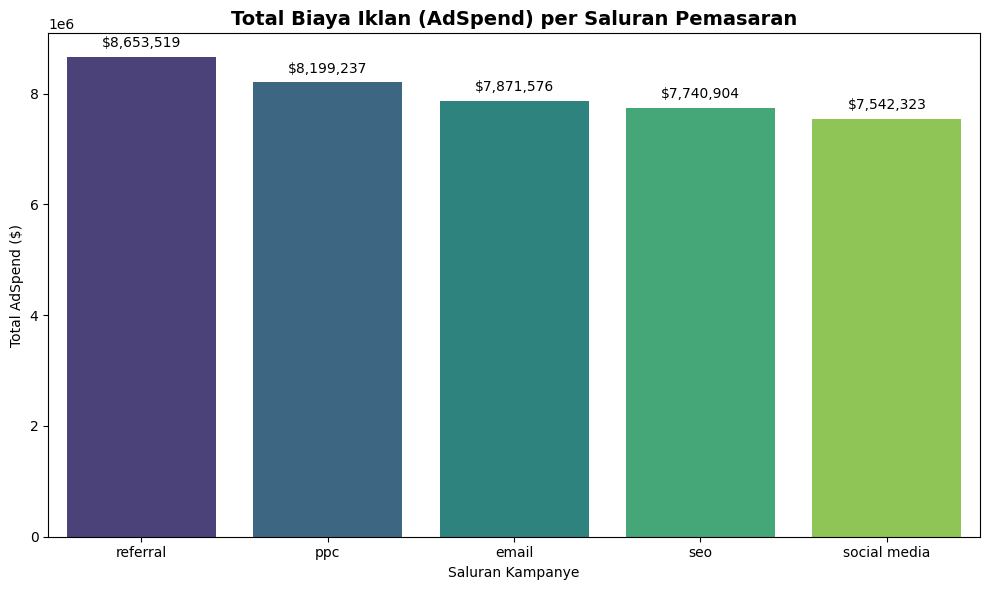

Berdasarkan data, 2 saluran termahal adalah: referral dan ppc


In [ ]:
# Mengelompokkan total AdSpend per saluran
channel_spend = df.groupby('CampaignChannel')['AdSpend'].sum().sort_values(ascending=False).reset_index()

# Menampilkan Vertical Bar Chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='CampaignChannel', y='AdSpend', data=channel_spend, palette='viridis')
plt.title('Total Biaya Iklan (AdSpend) per Saluran Pemasaran', fontsize=14, fontweight='bold')
plt.xlabel('Saluran Kampanye')
plt.ylabel('Total AdSpend ($)')

# Menambahkan label angka di atas tiap baris
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Mengunci 2 channel teratas untuk eksperimen
top_2_channels = channel_spend['CampaignChannel'].head(2).tolist()
print(f"Berdasarkan data, 2 saluran termahal adalah: {top_2_channels[0]} dan {top_2_channels[1]}")

## 3. Persiapan Data Eksperimen A/B Testing
Berdasarkan hasil EDA, 2 saluran termahal yang menyedot anggaran perusahaan adalah **Referral** dan **PPC**.
Kita akan memfilter data khusus untuk 2 saluran ini dan menghitung metrik finansial **CPA (Cost Per Acquisition)**. CPA agregat dihitung dengan membagi Total AdSpend dengan Total Konversi di masing-masing saluran.

In [ ]:
# Memfilter dataset hanya untuk Referral dan PPC
df_ab = df[df['CampaignChannel'].isin(['referral', 'ppc'])].copy()

# Menampilkan metrik agregat (Total Spend, Total Conversion, CPA) per saluran
agg_metrics = df_ab.groupby('CampaignChannel').agg(
    Total_AdSpend=('AdSpend', 'sum'),
    Total_Conversion=('Conversion', 'sum'),
    Total_Users=('CustomerID', 'count')
).reset_index()

# Menghitung CPA Agregat (Biaya untuk 1 konversi)
agg_metrics['CPA_Agregat'] = agg_metrics['Total_AdSpend'] / agg_metrics['Total_Conversion']
agg_metrics['Conversion_Rate'] = (agg_metrics['Total_Conversion'] / agg_metrics['Total_Users']) * 100

print("Ringkasan Performa Referral vs PPC:")
display(agg_metrics)

# Menyimpan data eksperimen untuk tim Dashboard (Tableau/PowerBI)
df_ab.to_csv('ab_test_referral_ppc.csv', index=False)

Ringkasan Performa Referral vs PPC:


,CampaignChannel,Total_AdSpend,Total_Conversion,Total_Users,CPA_Agregat,Conversion_Rate
0,ppc,8.199237e+06,1461,1655,5612.071856,88.277946
1,referral,8.653519e+06,1518,1719,5700.605195,88.307155


## 4. Uji Hipotesis Statistik (Z-Test & T-Test)
Kita akan melakukan dua uji statistik untuk mengambil keputusan bisnis:
1. **Z-Test Proporsi (Konversi):** Menguji apakah rasio konversi antara Referral dan PPC memiliki perbedaan yang signifikan secara statistik.
2. **T-Test (Biaya Iklan/AdSpend):** Menguji apakah rata-rata biaya iklan yang dihabiskan per pengguna berbeda secara signifikan antara kedua saluran.

**Tingkat Signifikansi (Alpha):** 0.05

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Menyiapkan data untuk Z-Test
# Jumlah konversi (successes)
sukses = agg_metrics['Total_Conversion'].values
# Jumlah total pengguna (nobs)
total_observasi = agg_metrics['Total_Users'].values

# Melakukan Z-Test Proporsi
z_stat, p_val_z = proportions_ztest(count=sukses, nobs=total_observasi)

print("--- Hasil Z-Test (Conversion Rate) ---")
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value    : {p_val_z:.4f}")

if p_val_z < 0.05:
    print("Kesimpulan : Tolak H0. Ada perbedaan signifikan pada rasio konversi antara Referral dan PPC.")
else:
    print("Kesimpulan : Gagal tolak H0. Tidak ada perbedaan signifikan pada rasio konversi.")

--- Hasil Z-Test (Conversion Rate) ---
Z-Statistic: -0.0264
P-Value    : 0.9790
Kesimpulan : Gagal tolak H0. Tidak ada perbedaan signifikan pada rasio konversi.


In [ ]:
import scipy.stats as stats

# Memisahkan data AdSpend masing-masing grup
adspend_referral = df_ab[df_ab['CampaignChannel'] == 'referral']['AdSpend']
adspend_ppc = df_ab[df_ab['CampaignChannel'] == 'ppc']['AdSpend']

# Melakukan Independent T-Test (Welch's T-Test karena varians mungkin berbeda)
t_stat, p_val_t = stats.ttest_ind(adspend_referral, adspend_ppc, equal_var=False)

print("--- Hasil T-Test (Rata-rata AdSpend per Pengguna) ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value    : {p_val_t:.4f}")

if p_val_t < 0.05:
    print("Kesimpulan : Tolak H0. Ada perbedaan signifikan pada rata-rata pengeluaran iklan antara Referral dan PPC.")
else:
    print("Kesimpulan : Gagal tolak H0. Tidak ada perbedaan signifikan pada rata-rata pengeluaran iklan.")

--- Hasil T-Test (Rata-rata AdSpend per Pengguna) ---
T-Statistic: 0.8109
P-Value    : 0.4175
Kesimpulan : Gagal tolak H0. Tidak ada perbedaan signifikan pada rata-rata pengeluaran iklan.


"Perusahaan saat ini mengalokasikan anggaran terbesar ke PPC dan Referral, padahal secara statistik keduanya memberikan tingkat konversi dan memakan biaya akuisisi yang sama persis. Tidak ada competitive advantage (keunggulan mutlak) dari salah satu saluran jika kita memukul rata semua pelanggan."

## 4B. Uji Kualitas Pelanggan (Post-Conversion A/B Testing)
Karena hasil uji konversi dan efisiensi biaya menunjukkan performa yang setara antara **Referral** dan **PPC**, kita perlu mengevaluasi *kualitas* dari pelanggan yang berhasil diakuisisi.

Kita akan menggunakan **Independent T-Test** untuk membandingkan rata-rata `LoyaltyPoints` khusus pada audiens yang **sudah terkonversi (Conversion = 1)** dari kedua saluran tersebut. Ini akan menentukan kampanye mana yang mendatangkan *High-Value Customers* untuk jangka panjang.

In [ ]:
import scipy.stats as stats

# 1. Memfilter data HANYA untuk pelanggan yang sudah terkonversi (membeli)
df_converted = df_ab[df_ab['Conversion'] == 1].copy()

# 2. Memisahkan data LoyaltyPoints berdasarkan saluran
loyalty_referral = df_converted[df_converted['CampaignChannel'] == 'referral']['LoyaltyPoints']
loyalty_ppc = df_converted[df_converted['CampaignChannel'] == 'ppc']['LoyaltyPoints']

# 3. Menghitung rata-rata (Mean) untuk melihat siapa yang lebih tinggi secara angka
mean_referral = loyalty_referral.mean()
mean_ppc = loyalty_ppc.mean()

print("--- Ringkasan Kualitas Pelanggan (Loyalty Points) ---")
print(f"Rata-rata Poin Loyalitas (Referral) : {mean_referral:.2f}")
print(f"Rata-rata Poin Loyalitas (PPC)      : {mean_ppc:.2f}\n")

# 4. Melakukan T-Test untuk membuktikan signifikansi perbedaannya
t_stat_loyalty, p_val_loyalty = stats.ttest_ind(loyalty_referral, loyalty_ppc, equal_var=False)

print("--- Hasil T-Test (Signifikansi Statistik) ---")
print(f"T-Statistic: {t_stat_loyalty:.4f}")
print(f"P-Value    : {p_val_loyalty:.4f}\n")

# 5. Kesimpulan Otomatis
if p_val_loyalty < 0.05:
    pemenang = "Referral" if mean_referral > mean_ppc else "PPC"
    print(f"Kesimpulan Bisnis: Tolak H0. Pelanggan dari saluran {pemenang} terbukti secara signifikan memiliki loyalitas yang lebih tinggi.")
else:
    print("Kesimpulan Bisnis: Gagal tolak H0. Tidak ada perbedaan loyalitas yang signifikan antara pembeli dari Referral maupun PPC.")

--- Ringkasan Kualitas Pelanggan (Loyalty Points) ---
Rata-rata Poin Loyalitas (Referral) : 2518.13
Rata-rata Poin Loyalitas (PPC)      : 2485.67

--- Hasil T-Test (Signifikansi Statistik) ---
T-Statistic: 0.6298
P-Value    : 0.5289

Kesimpulan Bisnis: Gagal tolak H0. Tidak ada perbedaan loyalitas yang signifikan antara pembeli dari Referral maupun PPC.


## 5. A/B Testing Mid-Funnel (Engagement Analysis)
Karena uji makro pada ujung funnel (Konversi) menunjukkan hasil yang setara, analisis difokuskan pada tahap *Mid-Funnel*. Kita akan menggunakan **Independent T-Test** untuk membandingkan kualitas interaksi pengunjung dari Referral dan PPC saat mereka berada di dalam *website*.

**Metrik yang diuji:**
1. **TimeOnSite:** Durasi pengunjung berada di *website*. Metrik ini mengindikasikan tingkat ketertarikan pada konten atau produk.
2. **PagesPerVisit:** Jumlah halaman yang dibuka per kunjungan. Mengindikasikan seberapa dalam pengunjung mengeksplorasi *website*.

In [ ]:
import scipy.stats as stats

# Memisahkan data metrik keterlibatan berdasarkan saluran
time_referral = df_ab[df_ab['CampaignChannel'] == 'referral']['TimeOnSite']
time_ppc = df_ab[df_ab['CampaignChannel'] == 'ppc']['TimeOnSite']

pages_referral = df_ab[df_ab['CampaignChannel'] == 'referral']['PagesPerVisit']
pages_ppc = df_ab[df_ab['CampaignChannel'] == 'ppc']['PagesPerVisit']

# Menampilkan Rata-rata
print("--- Ringkasan Rata-rata Keterlibatan (Mid-Funnel) ---")
print(f"TimeOnSite (Referral)   : {time_referral.mean():.2f} menit")
print(f"TimeOnSite (PPC)        : {time_ppc.mean():.2f} menit")
print(f"PagesPerVisit (Referral): {pages_referral.mean():.2f} halaman")
print(f"PagesPerVisit (PPC)     : {pages_ppc.mean():.2f} halaman\n")

# Melakukan T-Test Welch (equal_var=False karena varians bisa berbeda)
t_stat_time, p_val_time = stats.ttest_ind(time_referral, time_ppc, equal_var=False)
t_stat_pages, p_val_pages = stats.ttest_ind(pages_referral, pages_ppc, equal_var=False)

print("--- Hasil A/B Testing (P-Value) ---")
print(f"P-Value TimeOnSite    : {p_val_time:.4f}")
print(f"P-Value PagesPerVisit : {p_val_pages:.4f}\n")

# Logika Kesimpulan Otomatis
print("--- Kesimpulan Bisnis ---")
if p_val_time < 0.05:
    winner_time = "Referral" if time_referral.mean() > time_ppc.mean() else "PPC"
    print(f"[TimeOnSite] Tolak H0: Pengunjung dari saluran {winner_time} menghabiskan waktu signifikan lebih lama di website.")
else:
    print("[TimeOnSite] Gagal Tolak H0: Tidak ada perbedaan signifikan pada durasi kunjungan.")

if p_val_pages < 0.05:
    winner_pages = "Referral" if pages_referral.mean() > pages_ppc.mean() else "PPC"
    print(f"[PagesPerVisit] Tolak H0: Pengunjung dari saluran {winner_pages} mengeksplorasi halaman signifikan lebih banyak.")
else:
    print("[PagesPerVisit] Gagal Tolak H0: Tidak ada perbedaan signifikan pada jumlah halaman yang dibuka.")

--- Ringkasan Rata-rata Keterlibatan (Mid-Funnel) ---
TimeOnSite (Referral)   : 7.65 menit
TimeOnSite (PPC)        : 7.84 menit
PagesPerVisit (Referral): 5.54 halaman
PagesPerVisit (PPC)     : 5.55 halaman

--- Hasil A/B Testing (P-Value) ---
P-Value TimeOnSite    : 0.1878
P-Value PagesPerVisit : 0.8978

--- Kesimpulan Bisnis ---
[TimeOnSite] Gagal Tolak H0: Tidak ada perbedaan signifikan pada durasi kunjungan.
[PagesPerVisit] Gagal Tolak H0: Tidak ada perbedaan signifikan pada jumlah halaman yang dibuka.


## 6. A/B Testing Bias Demografi (Gender)
Karena strategi penargetan audiens yang terlalu luas (*Broad Targeting*) berisiko menyebabkan inefisiensi anggaran, analisis ini difokuskan pada evaluasi performa kampanye berdasarkan demografi audiens. Kita akan menggunakan **Z-Test Proporsi** dan **Independent T-Test** untuk membandingkan tingkat respons dan loyalitas antara audiens Pria dan Wanita.

**Metrik yang diuji:**
1. **Conversion:** Rasio keberhasilan audiens melakukan pembelian. Mengindikasikan demografi mana yang lebih mudah dibujuk oleh iklan.
2. **LoyaltyPoints:** Jumlah akumulasi poin pelanggan. Mengindikasikan demografi mana yang lebih setia dan bernilai untuk jangka panjang (*Long-Term Value*).

In [ ]:
print("\n=== A/B TESTING BIAS DEMOGRAFI (GENDER) ===")

# Asumsi isi kolom Gender adalah 'Male' dan 'Female' (atau 'male' dan 'female' jika sudah di-lowercase)
# Mengambil 2 gender unik teratas otomatis
genders = df['Gender'].unique()
grup_a_name, grup_b_name = genders[0], genders[1]

grup_a = df[df['Gender'] == grup_a_name]
grup_b = df[df['Gender'] == grup_b_name]

# Menampilkan Rata-rata Konversi
cr_a = grup_a['Conversion'].mean() * 100
cr_b = grup_b['Conversion'].mean() * 100
print(f"Conversion Rate ({grup_a_name.title()}) : {cr_a:.2f}%")
print(f"Conversion Rate ({grup_b_name.title()}) : {cr_b:.2f}%")

# 1. Uji Z-Test Proporsi (Siapa yang lebih gampang dibujuk beli?)
sukses_gender = np.array([grup_a['Conversion'].sum(), grup_b['Conversion'].sum()])
total_gender = np.array([len(grup_a), len(grup_b)])

z_stat_gender, p_val_gender = proportions_ztest(count=sukses_gender, nobs=total_gender)
print(f"P-Value Z-Test (Konversi) : {p_val_gender:.4f}")

if p_val_gender < 0.05:
    winner_gen = grup_a_name if cr_a > cr_b else grup_b_name
    print(f"Kesimpulan Konversi: Tolak H0. Demografi {winner_gen.title()} memiliki rasio konversi signifikan lebih tinggi.")
else:
    print("Kesimpulan Konversi: Gagal Tolak H0. Tidak ada perbedaan konversi yang signifikan antar gender.")

# 2. Uji T-Test (Loyalty Points - Siapa yang lebih setia untuk jangka panjang?)
loyalty_a = grup_a['LoyaltyPoints']
loyalty_b = grup_b['LoyaltyPoints']

t_stat_loyalty, p_val_loyalty = stats.ttest_ind(loyalty_a, loyalty_b, equal_var=False)
print(f"\nP-Value T-Test (Loyalty)  : {p_val_loyalty:.4f}")

if p_val_loyalty < 0.05:
    winner_loyalty = grup_a_name if loyalty_a.mean() > loyalty_b.mean() else grup_b_name
    print(f"Kesimpulan Loyalitas: Tolak H0. Demografi {winner_loyalty.title()} terbukti menjadi pelanggan yang jauh lebih loyal.")
else:
    print("Kesimpulan Loyalitas: Gagal Tolak H0. Tingkat loyalitas jangka panjang setara.")
print("-" * 50)


=== SKENARIO 3: A/B TESTING BIAS DEMOGRAFI (GENDER) ===
Conversion Rate (Female) : 87.62%
Conversion Rate (Male) : 87.69%
P-Value Z-Test (Konversi) : 0.9234
Kesimpulan Konversi: Gagal Tolak H0. Tidak ada perbedaan konversi yang signifikan antar gender.

P-Value T-Test (Loyalty)  : 0.6798
Kesimpulan Loyalitas: Gagal Tolak H0. Tingkat loyalitas jangka panjang setara.
--------------------------------------------------
